# K-means Clustering

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

## Imports

In [1]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
tracks_df = pd.read_csv("../datasets/tracks_cleaned.csv")

In [3]:
# Print all feature names
tracks_original_features = tracks_df.columns.tolist()
print(tracks_original_features)

# Print total number of features
print(f"\nTotal number of features: {len(tracks_original_features)}")

['swear_IT', 'swear_EN', 'year', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'album_type', 'explicit', 'popularity', 'duration_sec', 'swear_ratio', 'aggressiveness', 'relative_popularity', 'release_season', 'has_collaboration', 'song_age']

Total number of features: 26


## Features Selection

We tried to select features that capture different aspects, like: linguistic, audio, popularity, etc.

In [4]:
selected_features = [
    # linguistic / lyrics
    # 'n_tokens',
    # 'swear_IT',
    # 'lexical_density',

    # audio features
    # 'bpm',
    'centroid',
    'loudness',
    'spectral_complexity',
    # 'flux',
    'rolloff',

    # popularity
    'popularity',
    # 'relative_popularity',

    # time-related
    # 'season_autumn', 'season_spring', 'season_summer', 'season_winter',

    # engineered features
    # 'has_collaboration',
    'aggressiveness',
    # 'song_age',
    # 'duration_sec'
]

In [5]:
#Extract feature matrix
X = tracks_df[selected_features].copy()

## Preprocessing

In [6]:
# Check for NaN values
print(X.isna().sum())

centroid               0
loudness               0
spectral_complexity    0
rolloff                0
popularity             0
aggressiveness         0
dtype: int64


**Normalization**: We tried to normalize using both z-score and min-max, to see which one works best for different algorithms.

In [7]:
# Scale the features (z-score)
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_zscore = std_scaler.fit_transform(X)

In [8]:
# Scale the features (Min-Max)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

## K-Means

Train multiple KMeans models

In [9]:

from tqdm import tqdm


def run_kmeans_multiple(X, k_list, n_init=10, max_iter=300):
    """
    Train KMeans for multiple values of K.
    Returns:
        - list of KMeans models
        - SSE (inertia) list
        - Silhouette score list
    """
    kmeans_models = []
    sse_list = []
    silhouette_list = []

    for k in tqdm(k_list):
        kmeans = KMeans(n_clusters=k, n_init=n_init, max_iter=max_iter)
        kmeans.fit(X)

        kmeans_models.append(kmeans)
        sse_list.append(kmeans.inertia_)

        # Compute silhouette score if possible
        try:
            sil = silhouette_score(X, kmeans.labels_)
        except:
            sil = np.nan

        silhouette_list.append(sil)

        print(f"K={k}  | SSE={kmeans.inertia_:.2f} | Silhouette={sil:.4f}")

    return kmeans_models, sse_list, silhouette_list


Run KMeans for different values of k

In [10]:
k_list = list(range(2, 10))

kmeans_list, sse_list, silhouette_list = run_kmeans_multiple(
    X_minmax,
    k_list,
    n_init=10,
    max_iter=300
)


 12%|█▎        | 1/8 [00:05<00:40,  5.83s/it]

K=2  | SSE=1448.90 | Silhouette=0.2363


 25%|██▌       | 2/8 [00:09<00:27,  4.61s/it]

K=3  | SSE=1231.30 | Silhouette=0.2038


 38%|███▊      | 3/8 [00:13<00:20,  4.12s/it]

...

K=7  | SSE=846.16 | Silhouette=0.1764


 88%|████████▊ | 7/8 [00:28<00:04,  4.01s/it]

K=8  | SSE=805.10 | Silhouette=0.1641


100%|██████████| 8/8 [00:33<00:00,  4.19s/it]

K=9  | SSE=765.05 | Silhouette=0.1664


Plot SSE (Elbow Method)

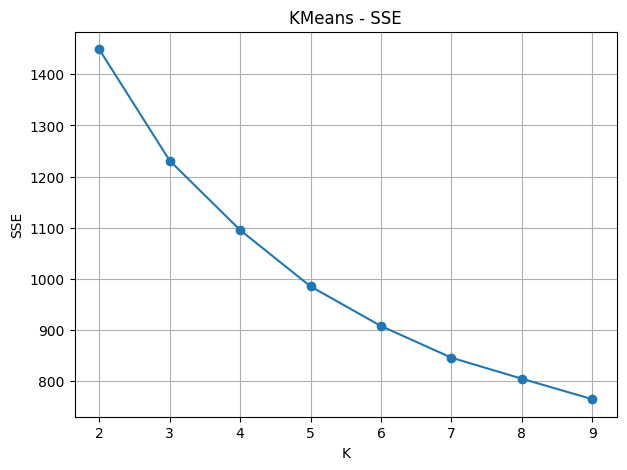

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(k_list, sse_list, marker='o')
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('KMeans - SSE')
plt.grid(True)
plt.show()


Plot Silhouette Scores

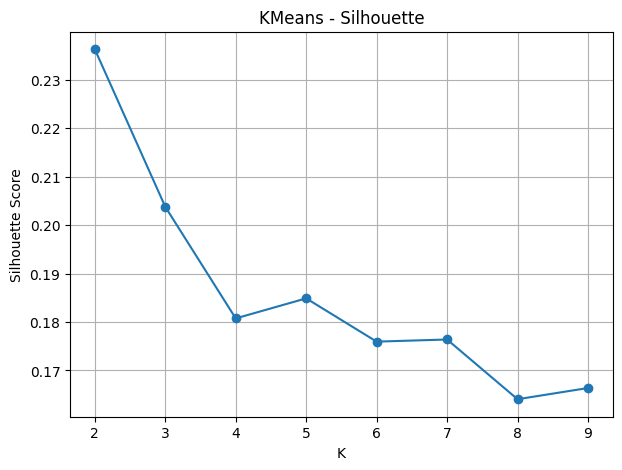

In [12]:
plt.figure(figsize=(7,5))
plt.plot(k_list, silhouette_list, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('KMeans - Silhouette')
plt.grid(True)
plt.show()


Choose the best K after observing the graphs

In [13]:
best_k = 3
best_kmeans = kmeans_list[k_list.index(best_k)]
final_kmeans_clusters = best_kmeans.labels_

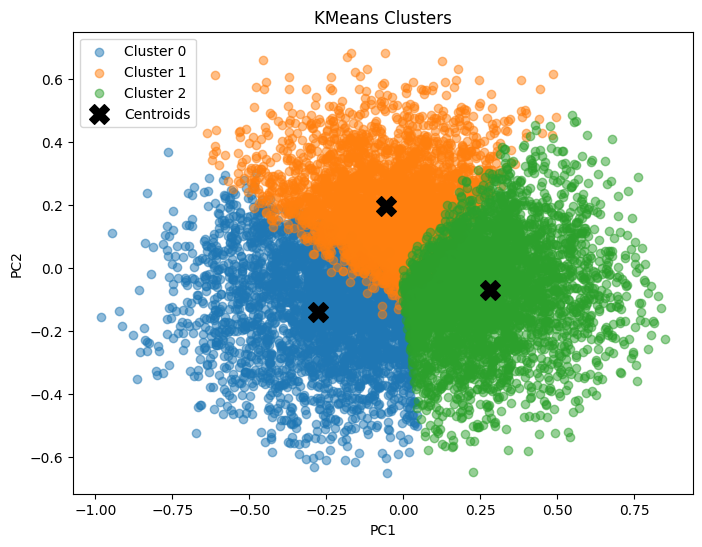

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_minmax)

# Transform cluster centers into PCA space
centroids_pca = pca.transform(best_kmeans.cluster_centers_)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(best_kmeans.n_clusters):
    plt.scatter(
        X_pca[final_kmeans_clusters == cluster, 0],
        X_pca[final_kmeans_clusters == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.5
    )

# Plot centroids
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=200,          # size
    c='black',      # color
    marker='X',     # marker shape
    label='Centroids'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters')
plt.legend()
plt.show()


Top Feature Importances

In [15]:
# Get the centroid matrix (K x F)
centroids = best_kmeans.cluster_centers_

# Compute variance of each feature across centroids
feature_importance = centroids.var(axis=0)

# Convert to a sorted Series
feature_importance_series = pd.Series(
    feature_importance,
    index=X.columns
).sort_values(ascending=False)

print("Feature importance from centroid variance:\n")
print(feature_importance_series)


Feature importance from centroid variance:

popularity             0.015640
centroid               0.014513
aggressiveness         0.013475
spectral_complexity    0.011497
rolloff                0.010741
loudness               0.009196
dtype: float64


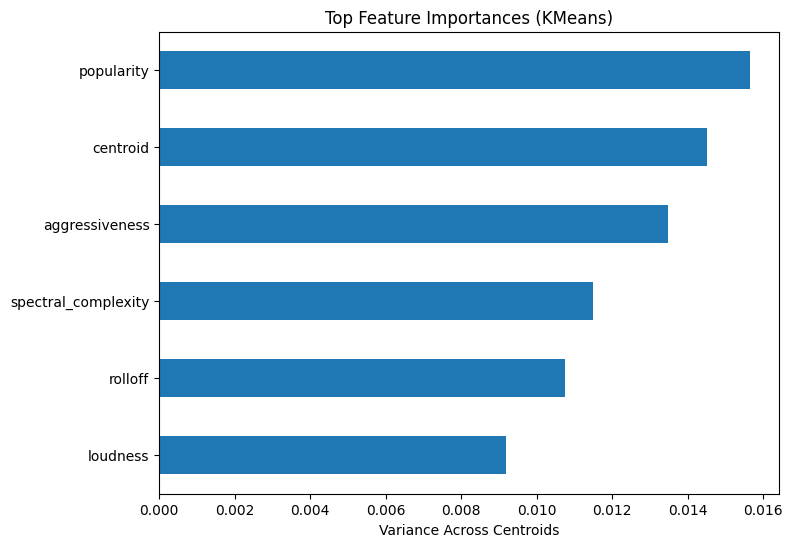

In [16]:
feature_importance_series.head(15).plot(kind='barh', figsize=(8,6))
plt.title("Top Feature Importances (KMeans)")
plt.xlabel("Variance Across Centroids")
plt.gca().invert_yaxis()
plt.show()


UMAP Cluster Visualization

c:\Users\Abdou\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Abdou\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


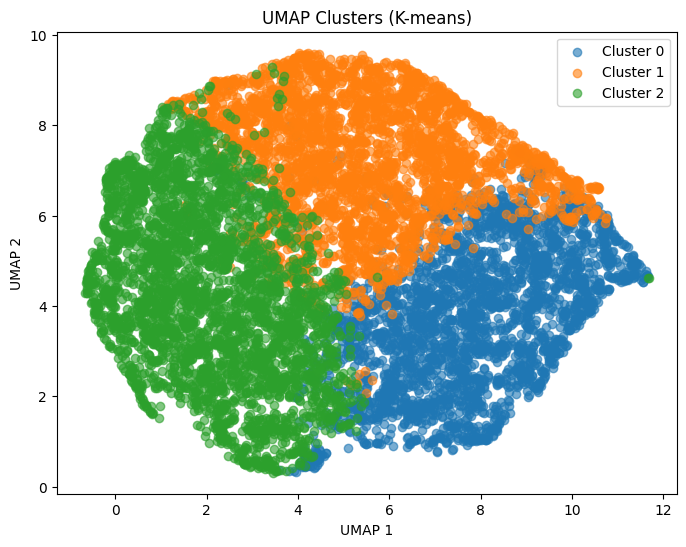

In [17]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

# Run UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_minmax)

# Plot
plt.figure(figsize=(8,6))
for cluster in range(best_kmeans.n_clusters):
    plt.scatter(
        X_umap[final_kmeans_clusters == cluster, 0],
        X_umap[final_kmeans_clusters == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.title("UMAP Clusters (K-means)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()


## Analysis of Final K-Means

Cluster size distribution

Cluster sizes: [np.int64(3069), np.int64(3475), np.int64(3728)]


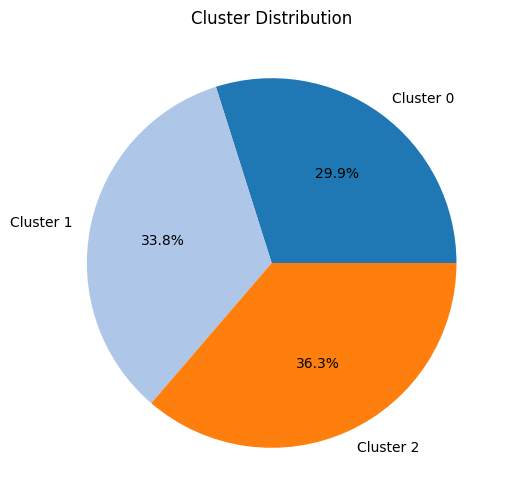

In [19]:
clusters = final_kmeans_clusters

n_clusters = len(np.unique(clusters))

# Count how many points per cluster
occ_list = [np.sum(clusters == k) for k in range(n_clusters)]

print("Cluster sizes:", occ_list)

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    occ_list,
    labels=[f"Cluster {k}" for k in range(n_clusters)],
    colors=sns.color_palette("tab20", n_clusters),
    autopct='%1.1f%%'
)
plt.title("Cluster Distribution")
plt.show()


Characterization of clusters

In [20]:
# Inspect the centroids

centroids = pd.DataFrame(
    best_kmeans.cluster_centers_,
    columns=X.columns
)
print(centroids)

   centroid  loudness  spectral_complexity   rolloff  popularity  \
0  0.380887  0.368551             0.371614  0.467248    0.262952   
1  0.459934  0.588246             0.506549  0.491513    0.529892   
2  0.666628  0.550375             0.634221  0.698222    0.266285   

   aggressiveness  
0        0.353396  
1        0.505505  
2        0.637495  


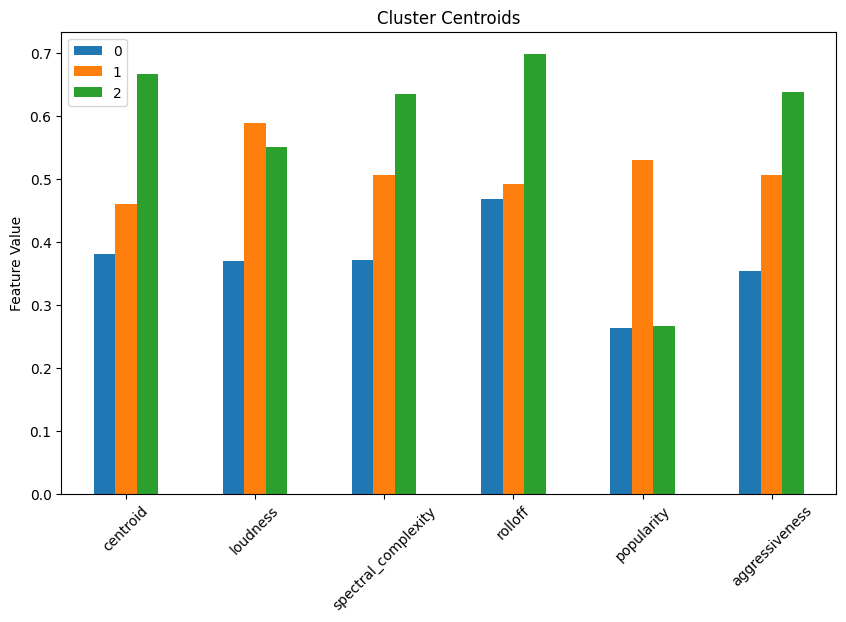

In [21]:
# Use barplot
centroids.T.plot(kind='bar', figsize=(10,6))
plt.title("Cluster Centroids")
plt.ylabel("Feature Value")
plt.xticks(rotation=45)
plt.show()

Compare feature distributions (cluster vs global)

Cluster means vs Dataset mean:

              centroid   loudness  spectral_complexity   rolloff  popularity  \
0             0.120231  18.469821            21.768710  6.012366   24.462366   
1             0.131595  28.290737            27.761143  6.085784   49.285755   
2             0.161186  26.592255            33.394572  6.692949   24.733101   
dataset_mean  0.138939  24.740082            28.015295  6.284206   32.958333   

              aggressiveness  
0                  -0.399543  
1                   0.030792  
2                   0.403731  
dataset_mean        0.037569  

Deviation from dataset mean:

         centroid  loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                  
0       -0.018708 -6.270261            -6.246585 -0.271840   -8.495968   
1       -0.007344  3.550656            -0.254152 -0.198422   16.327422   
2        0.022247  1.852173             5.379277  0.408743   -8.225232   

         a

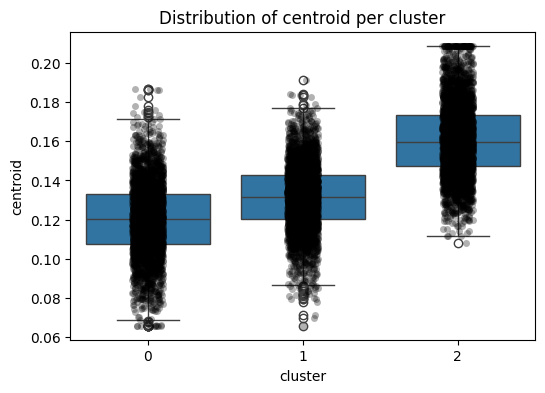

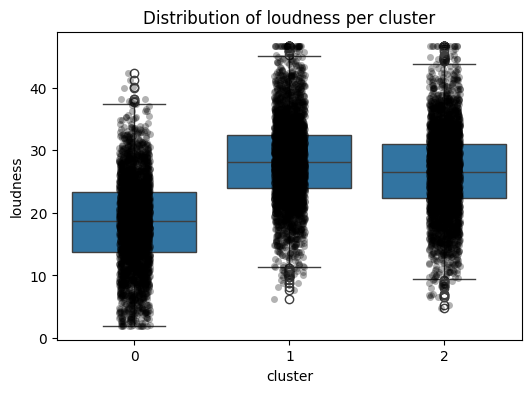

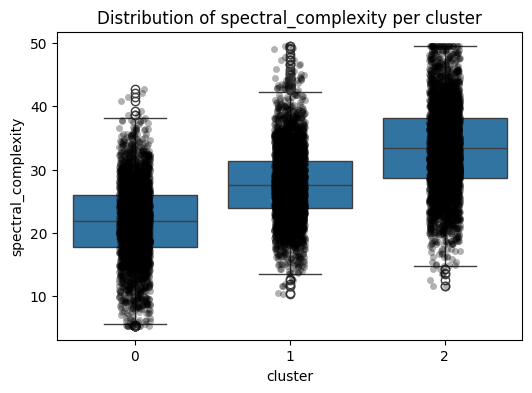

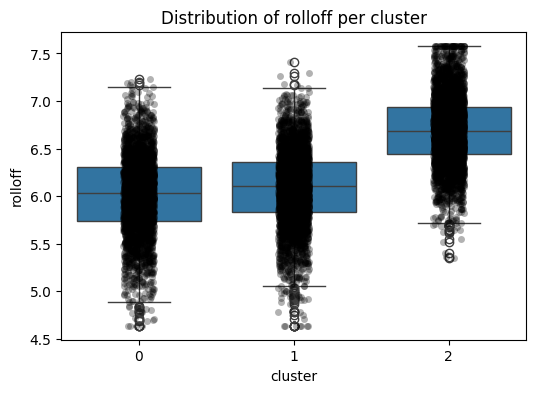

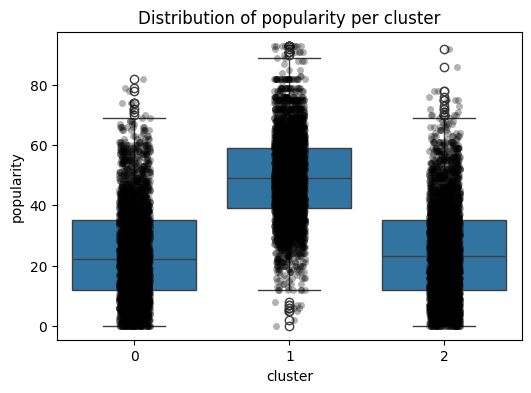

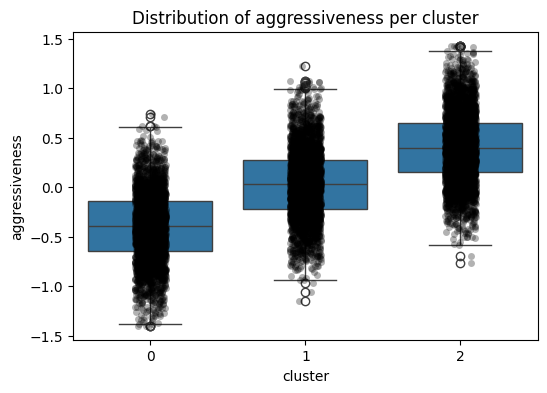

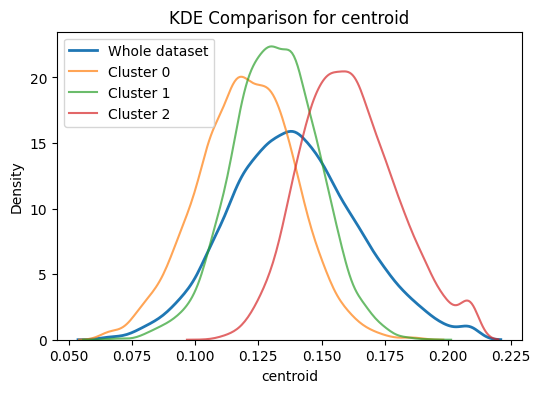

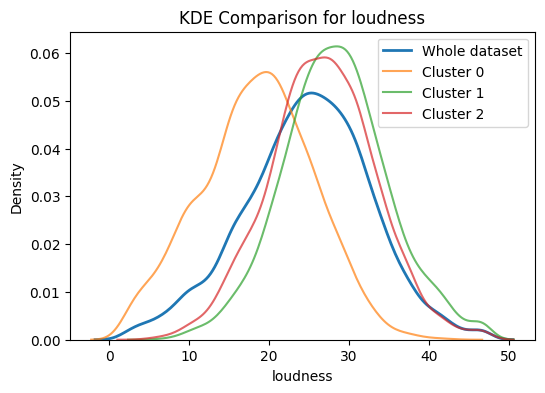

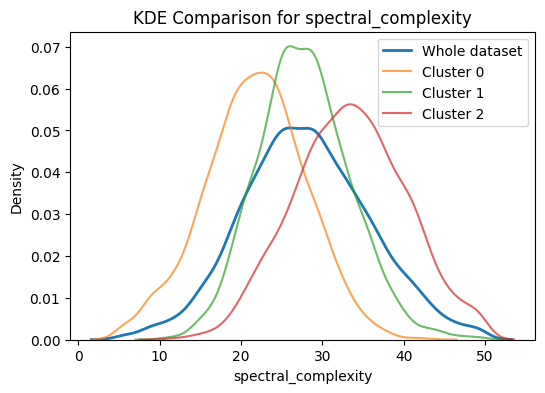

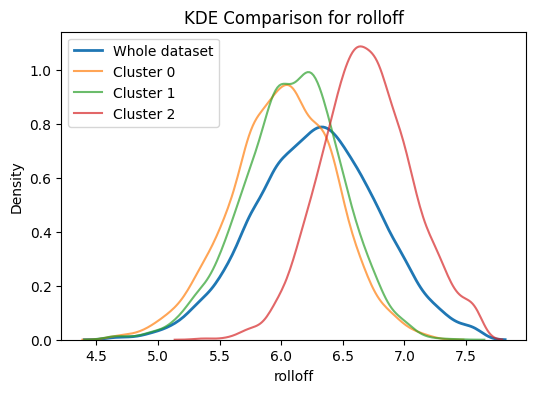

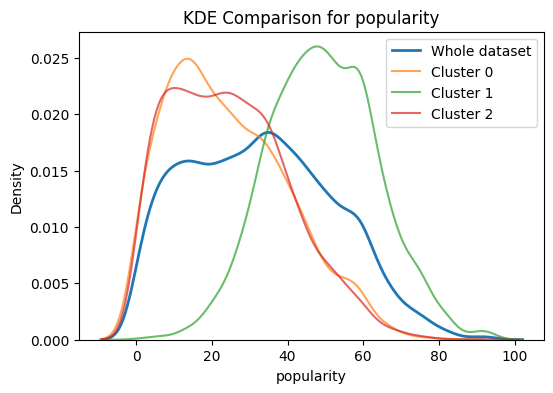

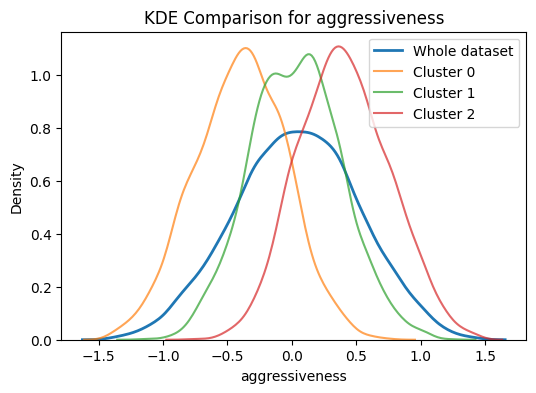

In [23]:
import pandas as pd
import numpy as np

# Create a dataframe with features + cluster labels
X_plot = X.copy()
X_plot['cluster'] = final_kmeans_clusters

# Compute cluster means and dataset mean
cluster_means = X_plot.groupby('cluster').mean()
dataset_mean = X.mean().to_frame().T
dataset_mean.index = ['dataset_mean']

# Combine with concat
summary = pd.concat([cluster_means, dataset_mean])

print("Cluster means vs Dataset mean:\n")
print(summary)

# Deviation from dataset mean
deviation = cluster_means - X.mean()
print("\nDeviation from dataset mean:\n")
print(deviation)

# Plot distributions with boxplots
import seaborn as sns
import matplotlib.pyplot as plt

for col in X.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=X_plot, x='cluster', y=col)
    sns.stripplot(data=X_plot, x='cluster', y=col, color='black', alpha=0.3)
    plt.title(f'Distribution of {col} per cluster')
    plt.show()

# KDE plots: cluster vs whole dataset
for col in X.columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(X[col], label='Whole dataset', linewidth=2)
    for cluster in np.unique(final_kmeans_clusters):
        sns.kdeplot(
            X_plot[X_plot.cluster == cluster][col],
            label=f'Cluster {cluster}',
            alpha=0.7
        )
    plt.title(f'KDE Comparison for {col}')
    plt.legend()
    plt.show()
